# Codigo de regresion Lineal y Analisis de datos entregados.

A continuacion, se muestra el codigo utilizado para analisis de datos, los cuales, luego de su analisis pasaran a ser utilizados para entrenar los modelos solicitados.

## Importacion y visualización de datos.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
cd /content/drive/MyDrive/colab/

/content/drive/MyDrive/colab


In [31]:
import pandas as pd

datos = pd.read_csv("./Dataset-4Clases-Tarea2.csv")


datos.head()

,Muestra,IRRADIANCE [W/m^2],TEMPERATURE [°C],ZENITH [deg],AZIMUTH [deg],ALBEDO,Vmpp,Impp,Pmpp,Fill Factor,Eficiencia
0,2020_01_05_05_54,0,14.9,155,-32,0.14,11.46,0.01,0.11,0.66826,0
1,2020_01_05_06_00,0,14.9,154,-34,0.14,12.88,0.01,0.17,0.69680,0
2,2020_01_05_06_05,0,14.9,154,-37,0.14,13.09,0.02,0.22,0.67886,0
3,2020_01_05_06_11,0,14.9,153,-39,0.14,13.67,0.03,0.45,0.71341,1
4,2020_01_05_06_17,0,14.9,152,-41,0.14,14.27,0.06,0.78,0.76495,2


### Inforamcion general de datos.

En esta seccion, se busca conocer informacion relevante de los datos:
- Cuantos hay.
- Cuanto varian las escalas entre ellos.
- Media de los datos.
- De que tipo son.

In [47]:
datos.info()
datos.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5208 entries, 0 to 5207
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Muestra             5208 non-null   object 
 1   IRRADIANCE [W/m^2]  5208 non-null   int64  
 2   TEMPERATURE [°C]    5208 non-null   float64
 3   ZENITH [deg]        5208 non-null   int64  
 4   AZIMUTH [deg]       5208 non-null   int64  
 5   ALBEDO              5208 non-null   float64
 6   Vmpp                5208 non-null   float64
 7   Impp                5208 non-null   float64
 8   Pmpp                5208 non-null   float64
 9   Fill Factor         5208 non-null   float64
 10  Eficiencia          5208 non-null   int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 447.7+ KB


,IRRADIANCE [W/m^2],TEMPERATURE [°C],ZENITH [deg],AZIMUTH [deg],ALBEDO,Vmpp,Impp,Pmpp,Fill Factor,Eficiencia
count,5208.000000,5208.000000,5208.000000,5208.000000,5208.000000,5208.000000,5208.000000,5208.000000,5208.000000,5208.000000
mean,279.140169,16.476728,77.779570,-71.611367,0.141167,15.246532,1.352339,19.529562,0.726646,1.500768
std,336.221754,4.012552,50.591855,54.807941,0.003211,1.216607,1.487783,19.815820,0.061635,1.121057
min,0.000000,11.000000,1.000000,-180.000000,0.140000,6.260000,0.000000,0.030000,0.318890,0.000000
25%,0.000000,13.200000,28.000000,-93.000000,0.140000,14.470000,0.270000,4.280000,0.697943,0.000000
50%,98.500000,14.700000,76.000000,-83.000000,0.140000,15.460000,0.720000,11.685000,0.745975,2.000000
75%,532.000000,20.000000,125.000000,-73.000000,0.140000,16.060000,1.812500,28.120000,0.764672,2.000000
max,1096.000000,26.500000,167.000000,180.000000,0.150000,19.270000,15.230000,76.740000,0.987490,3.000000


### Análisis de histograma de datos.

En esta seccion se busca cierta informacion determinante respecto a los datos, tales como su relevacia y sus sesgos.


array([[<Axes: title={'center': 'IRRADIANCE [W/m^2]'}>,
        <Axes: title={'center': 'TEMPERATURE [°C]'}>,
        <Axes: title={'center': 'ZENITH [deg]'}>],
       [<Axes: title={'center': 'AZIMUTH [deg]'}>,
        <Axes: title={'center': 'ALBEDO'}>,
        <Axes: title={'center': 'Vmpp'}>],
       [<Axes: title={'center': 'Impp'}>,
        <Axes: title={'center': 'Pmpp'}>,
        <Axes: title={'center': 'Fill Factor'}>],
       [<Axes: title={'center': 'Eficiencia'}>, <Axes: >, <Axes: >]],
      dtype=object)

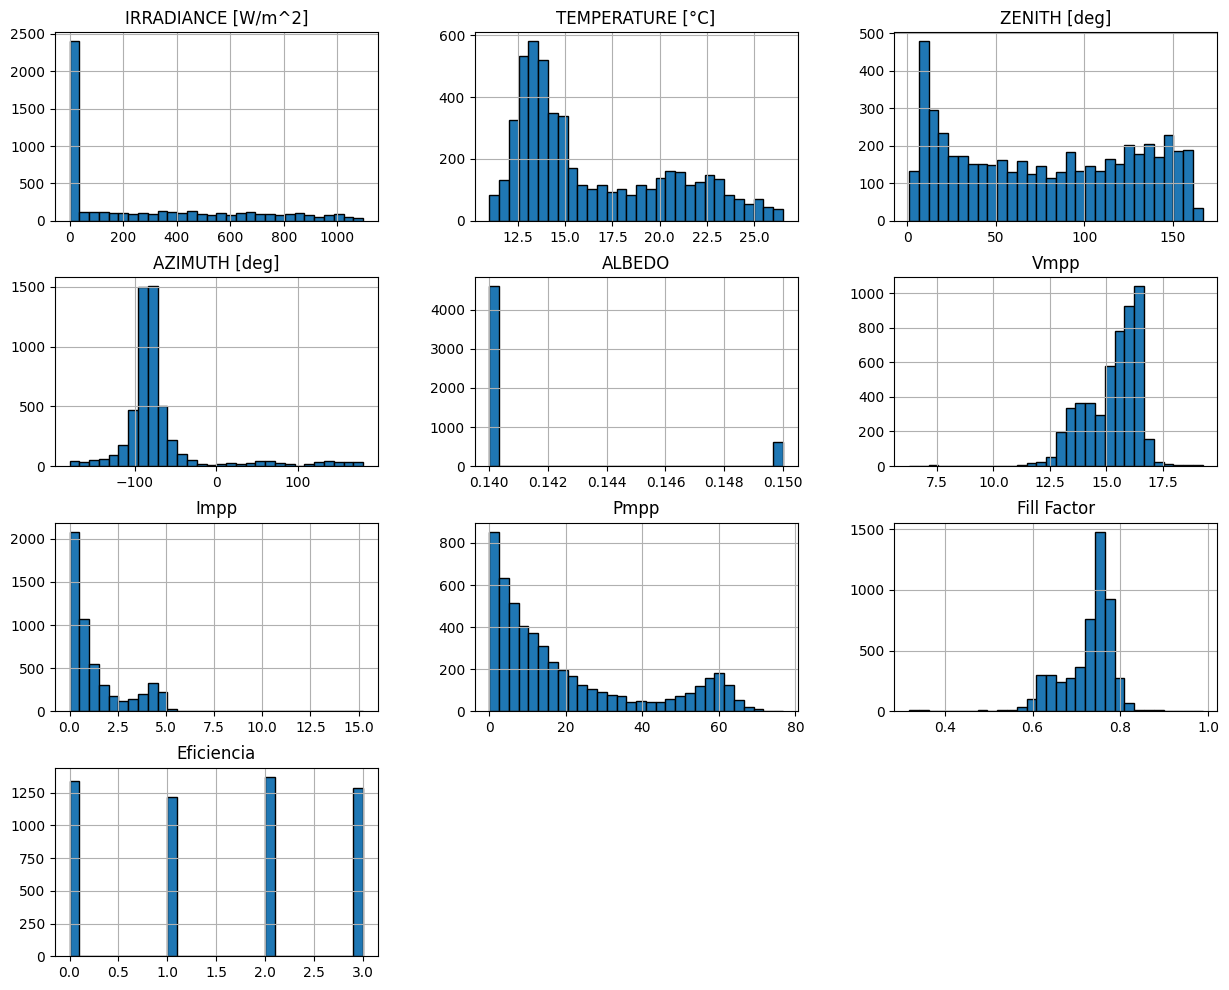

In [33]:
datos.hist(figsize=(15,12),bins=30, edgecolor="black")

### Análisis de relaciones.

En esta seccion se analisa como se relacionan los parametros de entrada con los de salida, adicionalmente, el como se relacionan entre si.

<Axes: >

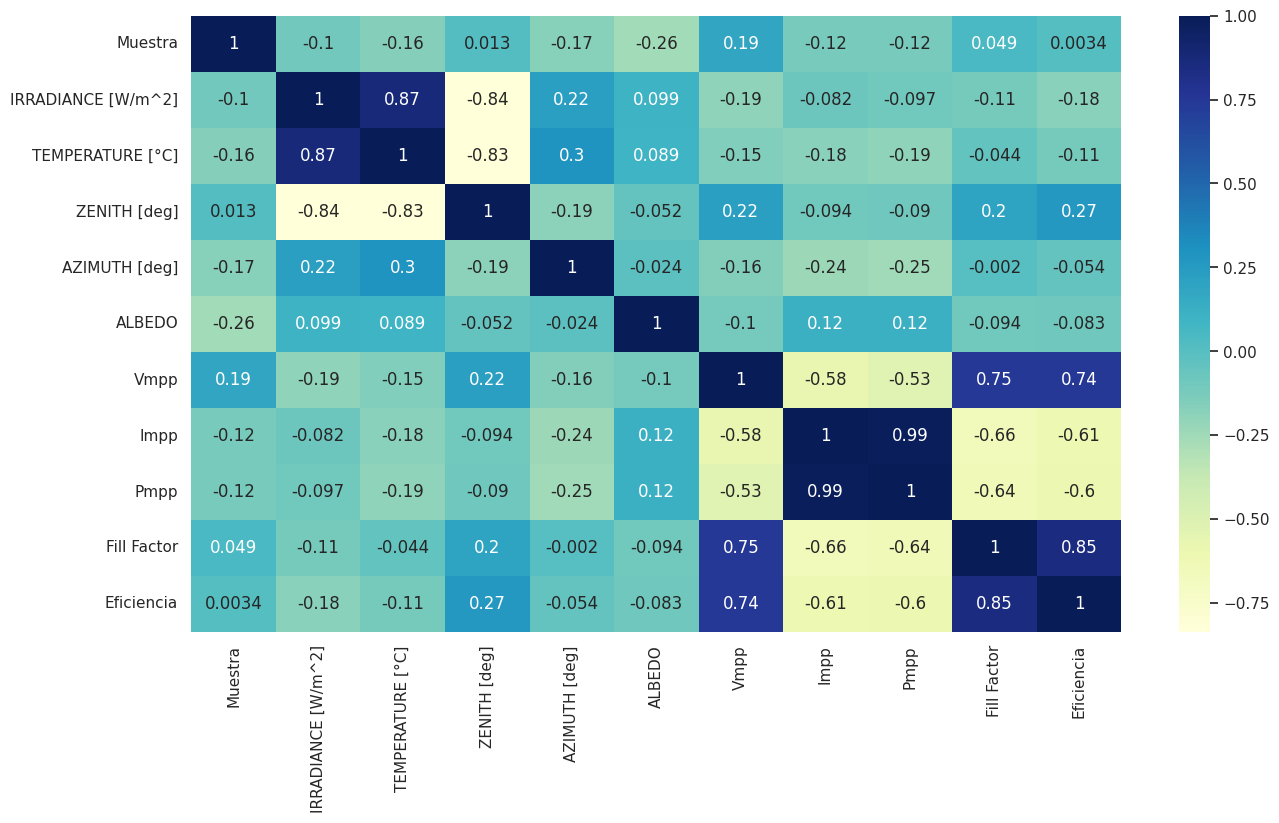

In [46]:
import seaborn as sb

sb.set(rc={'figure.figsize': (15,8)})
sb.heatmap(datos.corr(), annot=True,cmap='YlGnBu')

## Generacion de modelos y entrenamiento.

### Importacion de librerias.

In [7]:
from keras.models import Sequential
from keras.layers import Dense
from keras.models import model_from_json
from keras.callbacks import ModelCheckpoint
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
import pandas as pd
import numpy
from sklearn.model_selection import train_test_split, KFold, cross_val_score

## Tratamiento y separacion de datos.

En base a los analisis de las secciones anteriores, se tomo la decision de normalizar los datos, debido a la varianza y la diferencia de escalas entre estos.

Adicionalmente, se realizo la separacion entre datos de prueba y datos de entrenamiento.

In [8]:
scaler = StandardScaler()

seed = 2
numpy.random.seed(seed)

datos = pd.read_csv("Dataset-4Clases-Tarea2.csv")
dataset = datos.drop(['Muestra'],axis=1)                                    #<-- Eliminacion de columna de datos irrelevantes

x = dataset.drop(['Eficiencia','Fill Factor'],axis=1).values.astype(float)  #<-- extraccion parametro de entrada
y = dataset['Fill Factor'].values.astype(float)                             #<-- extraccion parametro de salida
x = scaler.fit_transform(x)                                                 #<-- normalizacion de datos de entrada

X, x_test, Y, y_test =  train_test_split(x,y,test_size=.2)                  #<-- separacion datos de prueba y entrenamiento


## Generacion de modelos.

In [9]:
#NOTE: Primer modelo de regresion lineal.
def linealRegretion1():

    modelo = Sequential([Dense(64, input_dim=8,  activation='relu'), #<-- capa de entrada.
                         Dense(64, activation='relu'),               #<-- capa oculta con 64 perceptrones.
                         Dense(1)])                                  #<-- capa de salida.

    modelo.compile(loss='mse', optimizer='rmsprop', metrics=['mae','accuracy'])

    return modelo

#NOTE: segundo modelo de regresion lineal.
def linealRegretion2():

    modelo = Sequential([Dense(64, input_dim=8,  activation='relu'), #<-- capa de entrada.
                         Dense(8, activation='relu'),                #<-- capa oculta con 8 perceptrones.
                         Dense(64, activation='sigmoid'),            #<-- capa oculta con 64 perceptrones.
                         Dense(1)])                                  #<-- capa de salida.

    modelo.compile(loss='mse', optimizer='rmsprop', metrics=['mae','accuracy'])

    return modelo


# Entrenamiento y guardado modelos.

In [11]:

cvscores = []

#NOTE: Generacion de Kfolds para cross validation con 4 carpetas.
kfold1 = KFold(n_splits=4, shuffle=True, random_state=seed)

#NOTE: implementacion de cross validation.
for train, val in kfold1.split(X, Y):

#NOTE: Primer modelo
    model1 = linealRegretion1()

#NOTE: Checkpoints.
    filepath="./weights_regretion1/weights-improvement-{epoch:02d}-{val_loss:.5f}.hdf5"                    #<--- ubicacion de checkpoints.
    checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=0, save_best_only=True, mode='min') #<--- generacion de checkpoints.
    callbacks_list = [checkpoint]

#NOTE: entrenamiento de modelo 1.
    entrenamiento1 = model1.fit(X[train],
                              Y[train],
                              epochs=400,
                              callbacks=callbacks_list,
                              validation_data=(X[val],Y[val]),
                              batch_size=150,
                              verbose=0)

    scores = model1.evaluate(X[val], Y[val], verbose=0)
    print("%s: %.2f%%" % (model1.metrics_names[1], scores[1]*100))
    cvscores.append(scores[1] * 100)

print("%.2f%% (+/- %.2f%%)" % (numpy.mean(cvscores), numpy.std(cvscores)))

model_json = model1.to_json()

with open("regresion_model_guardado1.json", "w") as json_file:
    json_file.write(model_json)

#NOTE: convertir weights a HDF5
model1.save_weights("model_guardado1.h5")
print("Guardar modelo al disco")

mae: 2.30%
mae: 2.21%
mae: 1.86%
mae: 2.72%
2.27% (+/- 0.31%)
Guardar modelo al disco


In [36]:
cvscores = []

#NOTE: Generacion de Kfolds para cross validation con 4 carpetas.
kfold2 = KFold(n_splits=3, shuffle=True, random_state=seed)

#NOTE: implementacion de cross validation.
for train, val in kfold2.split(X, Y):

#NOTE: segundo modelo
    model2 = linealRegretion2()

#NOTE: Checkpoints.
    filepath="./weights_regretion2/weights-improvement-{epoch:02d}-{val_loss:.5f}.hdf5"                    #<--- ubicacion de checkpoints.
    checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=0, save_best_only=True, mode='min') #<--- generacion de checkpoints.
    callbacks_list = [checkpoint]

#NOTE: entrenamiento de modelo 1.
    entrenamiento2 = model2.fit(X[train],
                              Y[train],
                              epochs=600,
                              callbacks=callbacks_list,
                              validation_data=(X[val],Y[val]),
                              batch_size=200,
                              verbose=0)

    scores = model2.evaluate(X[val], Y[val], verbose=0)
    print("%s: %.2f%%" % (model2.metrics_names[1], scores[1]*100))
    cvscores.append(scores[1] * 100)

print("%.2f%% (+/- %.2f%%)" % (numpy.mean(cvscores), numpy.std(cvscores)))

model_json = model2.to_json()

with open("regresion_model_guardado2.json", "w") as json_file:
    json_file.write(model_json)

#NOTE: convertir weights a HDF5
model2.save_weights("model_guardado2.h5")
print("Guardar modelo al disco")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


mae: 3.28%
mae: 2.74%
mae: 2.11%
2.71% (+/- 0.48%)
Guardar modelo al disco


### Analisis general de precisión del modelo 1


In [13]:
def bestModel1(x):
    modelo = Sequential([Dense(64, input_dim=8,  activation='relu'),
                         Dense(64, activation='relu'),
                         Dense(1)])
    modelo.load_weights(x)
    modelo.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])

    return modelo


bestmodel1 = bestModel1('weights_regretion1/weights.best.hdf5')                   #<--- Generacion de modelo en base al mejor checkpoint.
predicciones = bestmodel1.predict(x_test)                                         #<--- Prediccion de los datos del mejor modelo.
predicts = {'predicciones': predicciones[:,0], 'Valor real': y_test}

pd.DataFrame(predicts)                                                            #<--- Genearcion de tabla comparativa

33/33 [==============================] - 0s 1ms/step


,predicciones,Valor real
0,0.607795,0.63791
1,0.793151,0.88663
2,0.762752,0.77381
3,0.736131,0.74686
4,0.695264,0.70028
...,...,...
1037,0.611710,0.59497
1038,0.709442,0.64419
1039,0.763546,0.76477
1040,0.744890,0.74034


### Analisis grafico del modelo 1.

Text(0.5, 0, 'épocas')

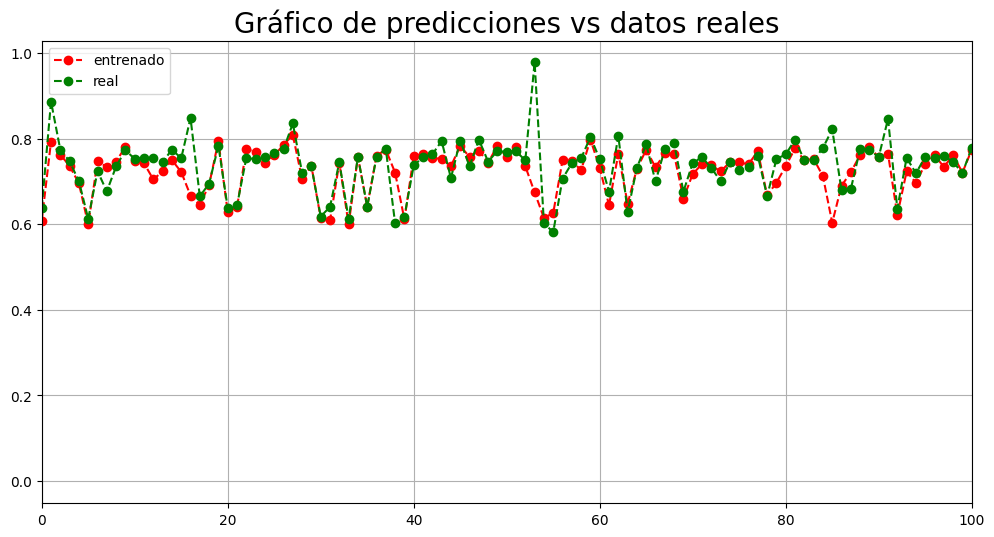

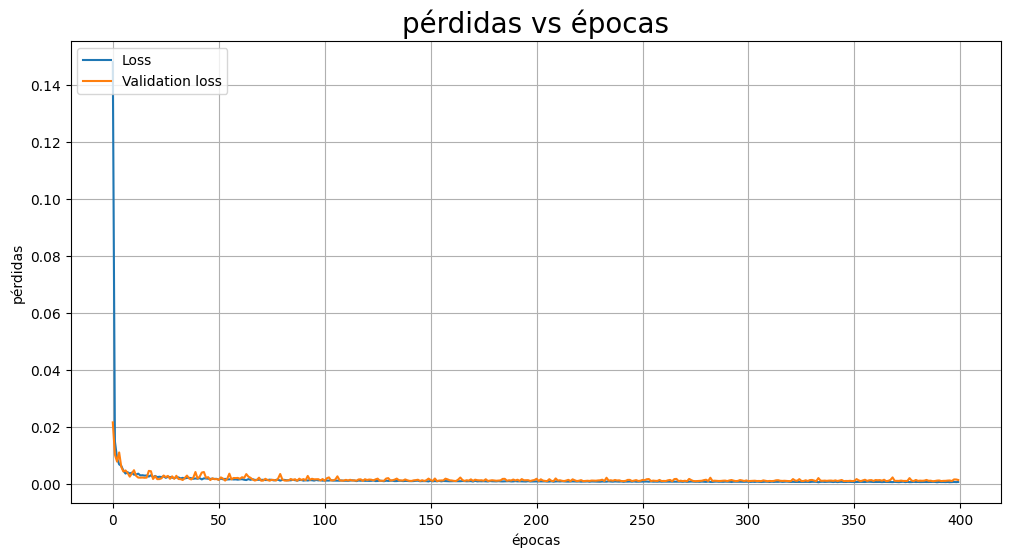

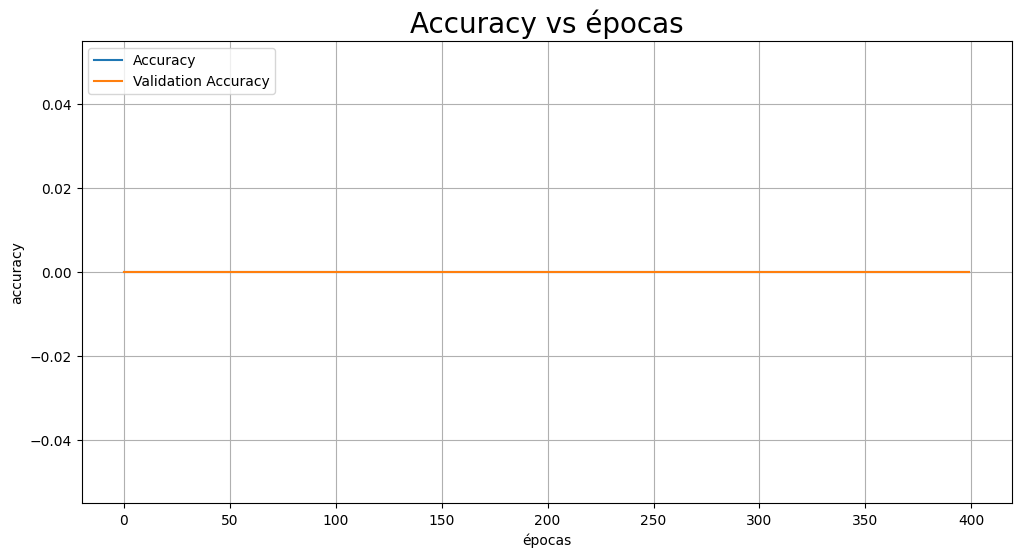

In [14]:


plt.figure(figsize=(12,6))
plt.plot(predicts['predicciones'], 'r--o', label="entrenado")
plt.plot(predicts['Valor real'], 'g--o', label="real")
plt.xlim([0,100])
plt.grid()
plt.legend(loc='upper left')
plt.title("Gráfico de predicciones vs datos reales", fontsize = 20)


plt.figure(figsize=(12,6))
plt.plot(entrenamiento1.history['loss'], label="Loss")
plt.plot(entrenamiento1.history['val_loss'], label="Validation loss")
plt.grid()
plt.legend(loc='upper left')
plt.title("pérdidas vs épocas", fontsize = 20)
plt.ylabel('pérdidas')
plt.xlabel('épocas')


plt.figure(figsize=(12,6))
plt.plot(entrenamiento1.history['accuracy'], label="Accuracy")
plt.plot(entrenamiento1.history['val_accuracy'], label="Validation Accuracy")
plt.grid()
plt.legend(loc='upper left')
plt.title("Accuracy vs épocas", fontsize = 20)
plt.ylabel('accuracy')
plt.xlabel('épocas')



### Analisis general de precisión del modelo 2


In [15]:
def bestModel2(x):
    modelo = Sequential([Dense(64, input_dim=8,  activation='relu'), #<-- capa de entrada.
                         Dense(8, activation='relu'),                #<-- capa oculta con 8 perceptrones.
                         Dense(64, activation='sigmoid'),            #<-- capa oculta con 64 perceptrones.
                         Dense(1)])                                  #<-- capa de salida.
    modelo.load_weights(x)
    modelo.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])

    return modelo


bestmodel2 = bestModel2('weights_regretion2/weights.best.hdf5')                   #<--- Generacion de modelo en base al mejor checkpoint.
predicciones = bestmodel2.predict(x_test)                                         #<--- Prediccion de los datos del mejor modelo.
predicts = {'predicciones': predicciones[:,0], 'Valor real': y_test}

pd.DataFrame(predicts)

33/33 [==============================] - 1s 2ms/step


,predicciones,Valor real
0,0.610333,0.63791
1,0.796800,0.88663
2,0.763069,0.77381
3,0.743801,0.74686
4,0.721763,0.70028
...,...,...
1037,0.617743,0.59497
1038,0.712746,0.64419
1039,0.766714,0.76477
1040,0.749394,0.74034


### Analisis grafico del modelo 2.

Text(0.5, 0, 'épocas')

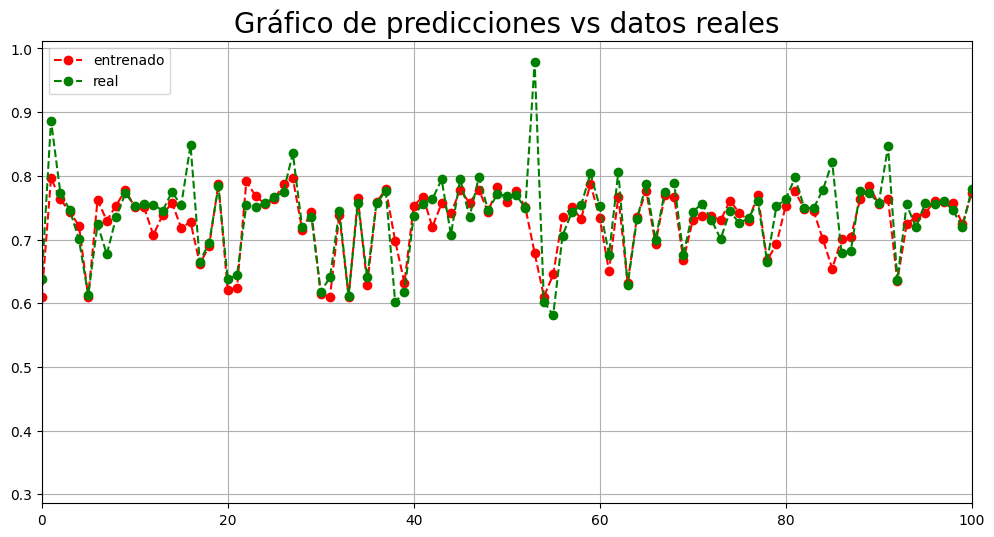

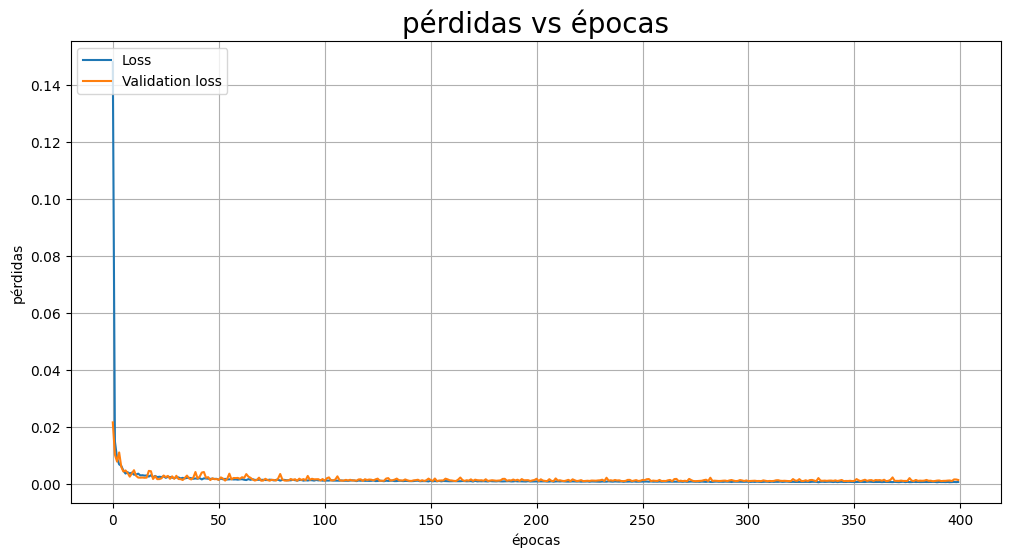

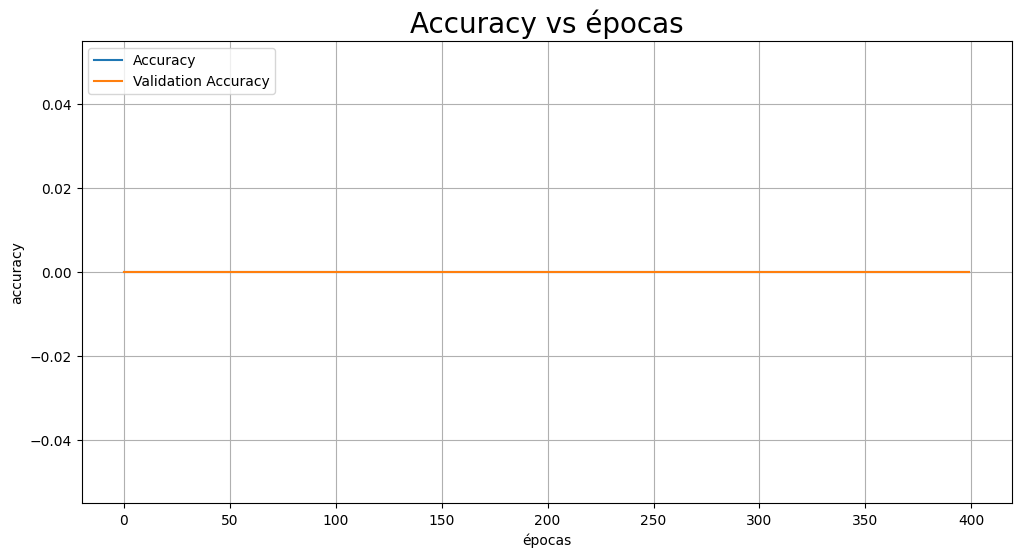

In [16]:
plt.figure(figsize=(12,6))
plt.plot(predicts['predicciones'], 'r--o', label="entrenado")
plt.plot(predicts['Valor real'], 'g--o', label="real")
plt.xlim([0,100])
plt.grid()
plt.legend(loc='upper left')
plt.title("Gráfico de predicciones vs datos reales", fontsize = 20)


plt.figure(figsize=(12,6))
plt.plot(entrenamiento1.history['loss'], label="Loss")
plt.plot(entrenamiento1.history['val_loss'], label="Validation loss")
plt.grid()
plt.legend(loc='upper left')
plt.title("pérdidas vs épocas", fontsize = 20)
plt.ylabel('pérdidas')
plt.xlabel('épocas')


plt.figure(figsize=(12,6))
plt.plot(entrenamiento1.history['accuracy'], label="Accuracy")
plt.plot(entrenamiento1.history['val_accuracy'], label="Validation Accuracy")
plt.grid()
plt.legend(loc='upper left')
plt.title("Accuracy vs épocas", fontsize = 20)
plt.ylabel('accuracy')
plt.xlabel('épocas')

### Comparativa ambos modelos

33/33 [==============================] - 0s 2ms/step


,modelo 1,modelo 2,Valor real
0,0.607795,0.610333,0.63791
1,0.793151,0.796800,0.88663
2,0.762752,0.763069,0.77381
3,0.736131,0.743801,0.74686
4,0.695264,0.721763,0.70028
...,...,...,...
1037,0.611710,0.617743,0.59497
1038,0.709442,0.712746,0.64419
1039,0.763546,0.766714,0.76477
1040,0.744890,0.749394,0.74034


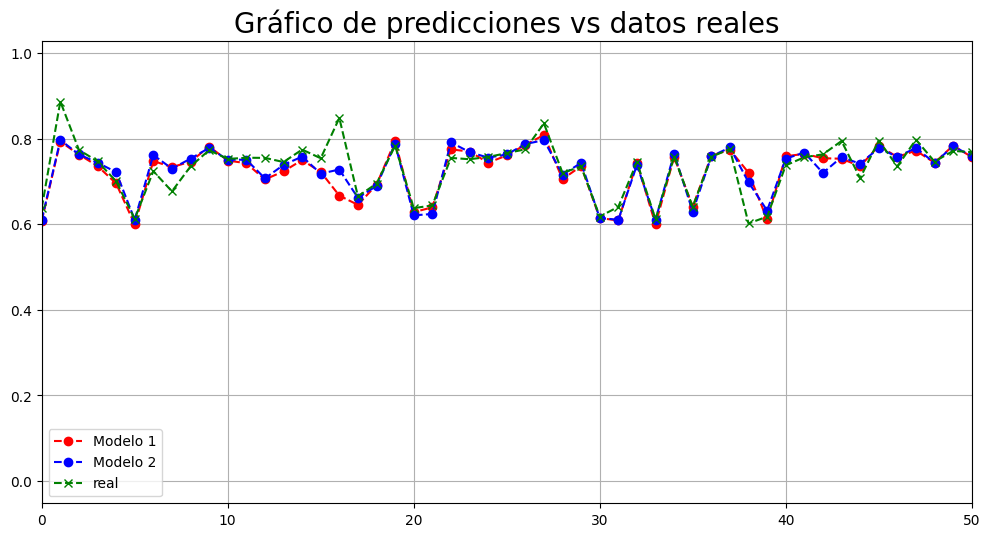

In [17]:
prediccion1 = bestmodel1.predict(x_test)
prediccion2 = bestmodel2.predict(x_test)
predicts = {'modelo 1': prediccion1[:,0],'modelo 2': prediccion2[:,0], 'Valor real': y_test}

plt.figure(figsize=(12,6))
plt.plot(predicts['modelo 1'], 'r--o', label="Modelo 1")
plt.plot(predicts['modelo 2'], 'b--o', label="Modelo 2")
plt.plot(predicts['Valor real'], 'g--x', label="real")
plt.xlim([0,50])
plt.grid()
plt.legend(loc='lower left')
plt.title("Gráfico de predicciones vs datos reales", fontsize = 20)

pd.DataFrame(predicts)